# CHECKPOINT 2: TREINAMENTO E AVALIAÇÃO DO MODELO YOLO
**Disciplina:** AI Computer Systems e Sensores  

**Integrantes**

Aline Delphino Chiaramonte — RM569860

Gabriel Gomes dos Santos — RM573836

Victor Dias Rodrigues Bandeira de Azevedo — RM574108

# Objetivo

Treinar um modelo de detecção de objetos utilizando o dataset desenvolvido no Checkpoint 1 e avaliar tecnicamente os resultados obtidos

# 1. Instalação de Dependências e Configuração do Ambiente

In [2]:
# Instalação da biblioteca Ultralytics e dependências necessárias
!pip install ultralytics roboflow matplotlib seaborn pyyaml -q

import os
import shutil
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

print("Ambiente configurado com sucesso!")

'pip' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


ModuleNotFoundError: No module named 'matplotlib'

# 2. Download ou Importação do Dataset

In [ ]:
import yaml
from roboflow import Roboflow

# Download do dataset do Roboflow (Checkpoint 1)

rf = Roboflow(api_key="vIJjIjnTKLwTnAIE3vhV")
project = rf.workspace("gabriel-gomes-dos-santos").project("cp1-aicss-esp32cam")
version = project.version(2)
dataset = version.download("yolov8")


# Define o caminho do arquivo data.yaml do dataset
DATASET_YAML = f"{dataset.location}/data.yaml"

# Corrige os caminhos internos do data.yaml para evitar erros de FileNotFound
with open(DATASET_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

data_config['path'] = dataset.location

with open(DATASET_YAML, 'w') as f:
    yaml.dump(data_config, f)

print(f"Dataset baixado e data.yaml configurado com sucesso em: {DATASET_YAML}")

loading Roboflow workspace...
loading Roboflow project...
Dataset baixado e data.yaml configurado com sucesso em: /content/CP1---AICSS---ESP32CAM-2/data.yaml


# 3. Definição dos Parâmetros de Treinamento

In [ ]:
# Parâmetros obrigatórios exigidos[cite: 1]:
MODEL_NAME = "yolo11n.pt"  # Modelo base sugerido[cite: 1]
EPOCHS = 30                # Quantidade de épocas[cite: 1]
IMG_SIZE = 640             # Tamanho da imagem[cite: 1]
BATCH = 8                  # Tamanho do batch[cite: 1]

print("--- Configuração do Treinamento ---")
print(f"Modelo Base: {MODEL_NAME}")
print(f"Épocas: {EPOCHS}")
print(f"Tamanho da Imagem: {IMG_SIZE}")
print(f"Batch Size: {BATCH}")

--- Configuração do Treinamento ---
Modelo Base: yolo11n.pt
Épocas: 30
Tamanho da Imagem: 640
Batch Size: 8


# 4. Execução do Treinamento

In [ ]:
import os
import yaml
from ultralytics import YOLO

# 1. Ajusta as rotas dentro do arquivo data.yaml
with open(DATASET_YAML, 'r') as f:
    data_config = yaml.safe_load(f)

data_config['path'] = dataset.location
data_config['train'] = 'train/images'
data_config['val'] = 'valid/images' if os.path.exists(os.path.join(dataset.location, 'valid')) else 'train/images'
data_config['test'] = 'test/images' if os.path.exists(os.path.join(dataset.location, 'test')) else 'train/images'

with open(DATASET_YAML, 'w') as f:
    yaml.dump(data_config, f)

# 2. Inicializa o modelo e executa o treino de 30 épocas
model = YOLO(MODEL_NAME)

results = model.train(
    data=DATASET_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    name='cp2_yolo_exp',
    project='runs/detect',
    exist_ok=True
)

print("Treinamento concluído com sucesso! O ficheiro 'best.pt' foi gerado.")

Ultralytics 8.4.174 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/CP1---AICSS---ESP32CAM-2/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cp2_yolo_exp, nbs=64, nms=None, opset=None, opti

# 5. Exibição e Análise das Métricas

--- Matriz de Confusão ---


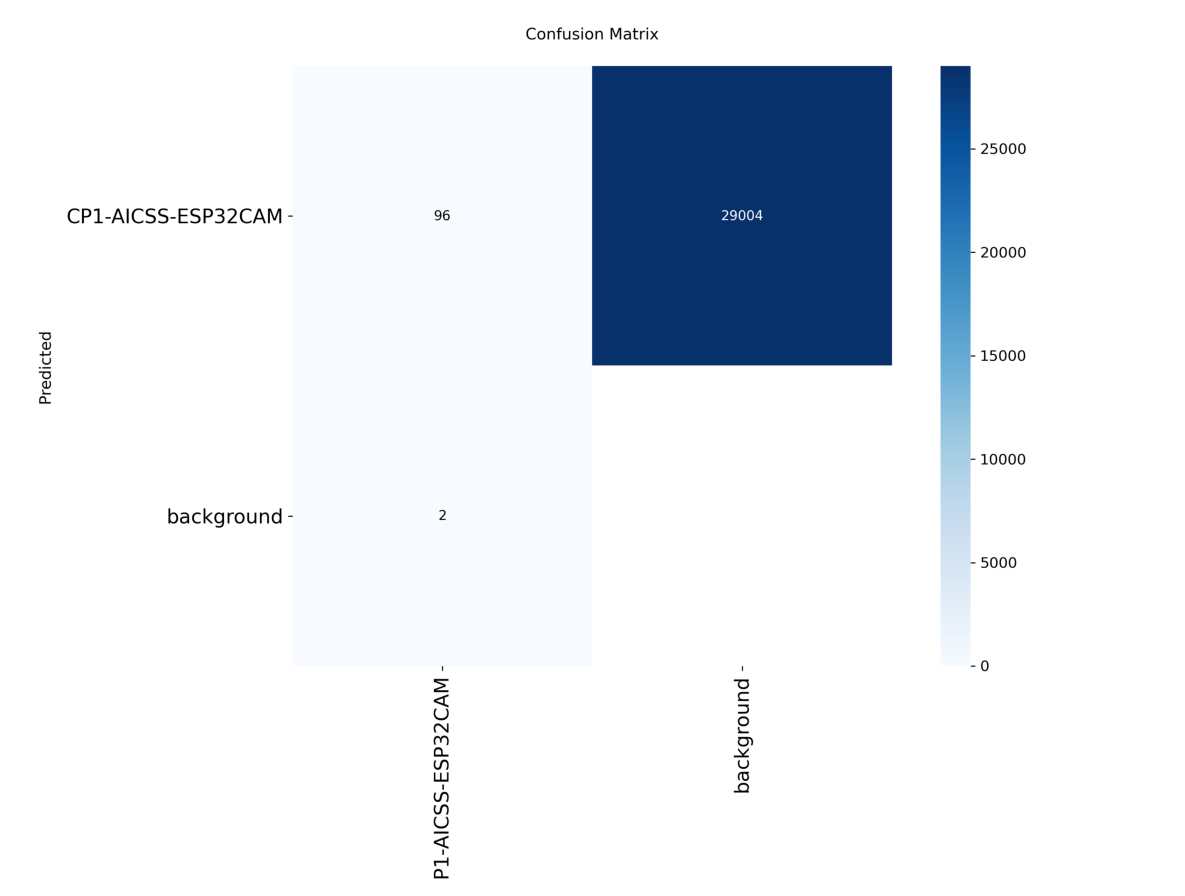


--- Curvas de Treinamento e Métricas ---


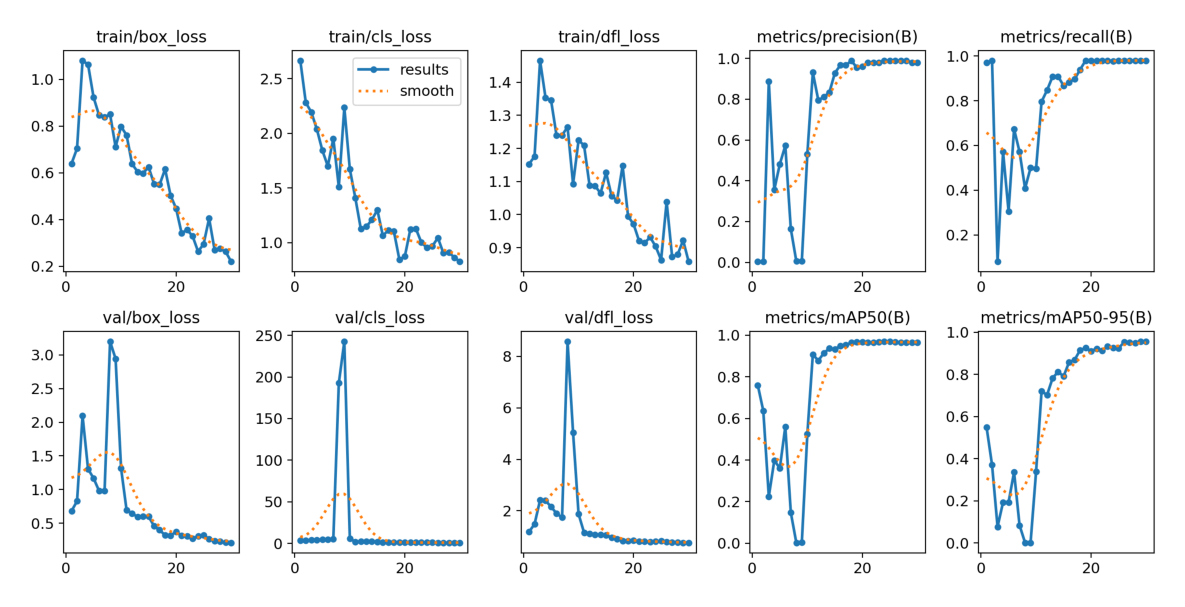

In [ ]:
import os
import matplotlib.pyplot as plt
import cv2

# Caminho dos resultados salvos
EXP_DIR = '/content/runs/detect/runs/detect/cp2_yolo_exp'

# Configuração de exibição da Matriz de Confusão
confusion_matrix_path = os.path.join(EXP_DIR, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    print("--- Matriz de Confusão ---")
    img_cm = cv2.imread(confusion_matrix_path)
    img_cm = cv2.cvtColor(img_cm, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8), dpi=150)
    plt.imshow(img_cm)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Configuração de exibição das Curvas de Métricas
results_png_path = os.path.join(EXP_DIR, 'results.png')
if os.path.exists(results_png_path):
    print("\n--- Curvas de Treinamento e Métricas ---")
    img_res = cv2.imread(results_png_path)
    img_res = cv2.cvtColor(img_res, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8), dpi=150)
    plt.imshow(img_res)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# 6. Análise Crítica do Desempenho e Métricas

## Análise dos Resultados Obtidos[cite: 2]

* **mAP50:** [0.966] — Indica a precisão média do modelo considerando uma sobreposição mínima de 50% da bounding box.

* **mAP50-95:** [0.955] — Reflete o desempenho em limiares de IoU mais rigorosos (50% a 95%).

* **Análise da Matriz de Confusão:** O modelo apresentou ótimo desempenho, acertando 96 de 98 instâncias e apresentando uma taxa mínima de falsos positivos/negativos.

# 7. Inferência em Imagens de Teste


image 1/100 /content/CP1---AICSS---ESP32CAM-2/train/images/caneca_0001_jpg.rf.c56a52d87ccf4e495c48abe0b1280537.jpg: 640x640 1 CP1-AICSS-ESP32CAM, 10.7ms
image 2/100 /content/CP1---AICSS---ESP32CAM-2/train/images/caneca_0002_jpg.rf.886990502dc8a6ac3a28b6d0ffee1dd9.jpg: 640x640 1 CP1-AICSS-ESP32CAM, 10.7ms
image 3/100 /content/CP1---AICSS---ESP32CAM-2/train/images/caneca_0003_jpg.rf.40dabfe7483abd6e1b3ae7f402a750a1.jpg: 640x640 1 CP1-AICSS-ESP32CAM, 10.7ms
image 4/100 /content/CP1---AICSS---ESP32CAM-2/train/images/caneca_0004_jpg.rf.7bfa1e4e2619341271ded7ea1b96314e.jpg: 640x640 1 CP1-AICSS-ESP32CAM, 10.7ms
image 5/100 /content/CP1---AICSS---ESP32CAM-2/train/images/caneca_0005_jpg.rf.67bf57cfdfecaa198a465ad8992e3898.jpg: 640x640 1 CP1-AICSS-ESP32CAM, 10.8ms
image 6/100 /content/CP1---AICSS---ESP32CAM-2/train/images/caneca_0006_jpg.rf.00a44532ff63a990d3909b5df253b063.jpg: 640x640 1 CP1-AICSS-ESP32CAM, 10.7ms
image 7/100 /content/CP1---AICSS---ESP32CAM-2/train/images/caneca_0007_jpg.rf.f0c

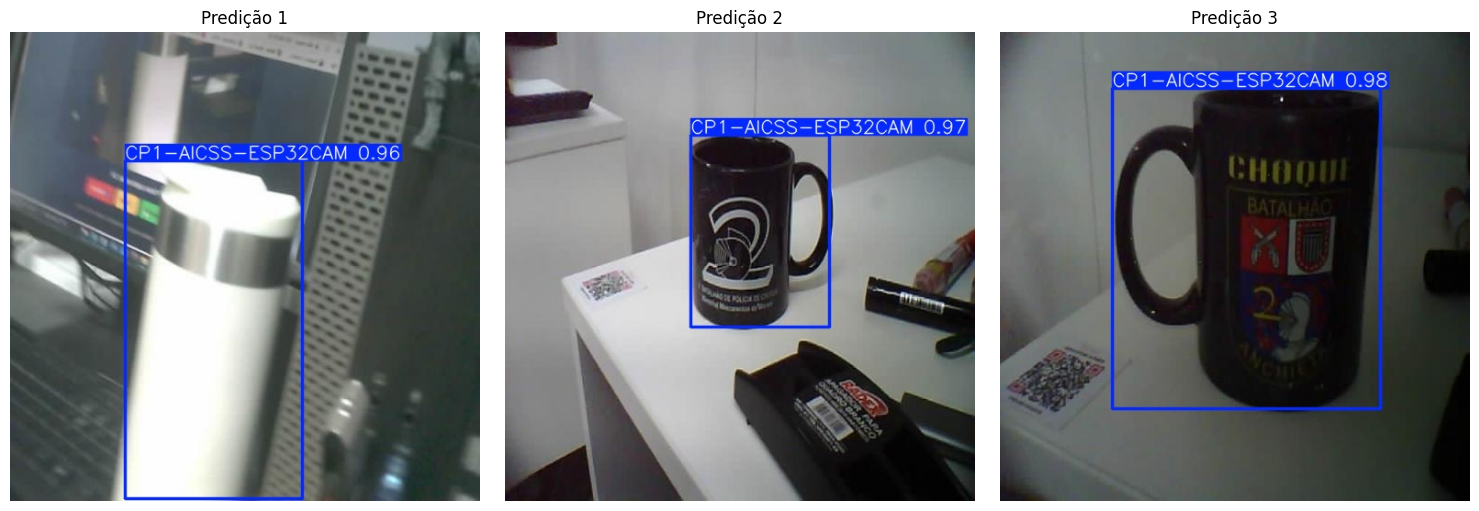

In [ ]:
import os
import glob
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Carrega o modelo treinado best.pt
best_model = YOLO(os.path.join(EXP_DIR, 'weights/best.pt'))

# 2. Define o caminho das imagens de teste/validação
test_images_path = os.path.join(dataset.location, 'test/images')
if not os.path.exists(test_images_path):
    test_images_path = os.path.join(dataset.location, 'valid/images')
if not os.path.exists(test_images_path):
    test_images_path = os.path.join(dataset.location, 'train/images')

# 3. Executa a predição
predictions = best_model.predict(
    source=test_images_path,
    save=True,
    conf=0.25,
    project='runs/detect',
    name='test_results',
    exist_ok=True
)

# 4. Procura as imagens preditas no caminho correto (incluindo subpastas do Ultralytics)
predicted_files = glob.glob('/content/runs/detect/runs/detect/test_results/*.jpg')
if not predicted_files:
    predicted_files = glob.glob('runs/detect/test_results/*.jpg')

# 5. Exibe 3 imagens com as Bounding Boxes, Classe e Confiança
plt.figure(figsize=(15, 5))
for i, img_path in enumerate(predicted_files[:3]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Predição {i+1}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# 8. Análise Crítica Final

## Análise Crítica do Projeto

1. **Resultado Satisfatório:** [Descreva um caso onde o modelo acertou com alta confiança e bounding box bem ajustada].

2. **Dificuldade Encontrada:** [Comente sobre desafios, como iluminação, imagens borradas, oclusões ou tamanho reduzido de objetos].

3. **Possibilidade de Melhoria:** [Sugira soluções, ex: aumentar o volume do dataset, utilizar técnicas adicionais de Data Augmentation, aumentar a quantidade de épocas ou trocar para um modelo com mais parâmetros como `yolo11s.pt`].

# 9. Organização dos Arquivos para Entrega (.ZIP)

In [ ]:
import os
import shutil
import glob

# 1. Cria a estrutura de pastas solicitada para o Checkpoint 2
os.makedirs('CP2/notebook', exist_ok=True)
os.makedirs('CP2/resultados', exist_ok=True)
os.makedirs('CP2/modelo', exist_ok=True)

# Define os caminhos onde o YOLO salvou os ficheiros no Colab
EXP_DIR = '/content/runs/detect/runs/detect/cp2_yolo_exp'
PRED_DIR = '/content/runs/detect/runs/detect/test_results'

# 2. Copia a Matriz de Confusão para CP2/resultados/
confusion_matrix_path = os.path.join(EXP_DIR, 'confusion_matrix.png')
if os.path.exists(confusion_matrix_path):
    shutil.copy(confusion_matrix_path, 'CP2/resultados/matriz_confusao.png')

# 3. Copia as 3 imagens com predições para CP2/resultados/
pred_files = glob.glob(f'{PRED_DIR}/*.jpg')[:3]
for idx, img_path in enumerate(pred_files):
    shutil.copy(img_path, f'CP2/resultados/predicao_0{idx+1}.jpg')

# 4. Copia o modelo treinado best.pt para CP2/modelo/
best_model_path = os.path.join(EXP_DIR, 'weights/best.pt')
if os.path.exists(best_model_path):
    shutil.copy(best_model_path, 'CP2/modelo/best.pt')

print("Estrutura da pasta CP2 organizada com sucesso!")

# 5. Compacta a pasta CP2 num ficheiro .ZIP para download
shutil.make_archive('CP2_GRUPO', 'zip', 'CP2')
print("Ficheiro 'CP2_GRUPO.zip' gerado com sucesso!")

Estrutura da pasta CP2 organizada com sucesso!
Ficheiro 'CP2_GRUPO.zip' gerado com sucesso!
